# Основные понятия и примеры прикладных задач

# Используемые пакеты

In [1]:
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

if IN_COLAB:
    !wget -q -O requirements.txt
    %pip install -q -r requirements.txt

In [2]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Ирисы Фишера
Выборка взята отсюда: https://archive.ics.uci.edu/ml/datasets/iris

## Загрузка выборки

In [3]:
dataset = pd.read_csv('https://raw.githubusercontent.com/andriygav/MachineLearningSeminars/master/sem1/data/iris.csv',
                      header=None,
                      names=['длина чашелистика', 'ширина чашелистика',
                             'длина лепестка', 'ширина лепестка', 'класс'])
dataset.sample(5, random_state=0)

,длина чашелистика,ширина чашелистика,длина лепестка,ширина лепестка,класс
114,5.8,2.8,5.1,2.4,Iris-virginica
62,6.0,2.2,4.0,1.0,Iris-versicolor
33,5.5,4.2,1.4,0.2,Iris-setosa
107,7.3,2.9,6.3,1.8,Iris-virginica
7,5.0,3.4,1.5,0.2,Iris-setosa


## Начало работы с данными
1. Определить множество объектов:
    * Определить размер выборки
    * Определить признаки, которыми описываются объекты
2. Определить множество ответов
3. Определить тип задачи машинного обучения
6. ...

### Множество объектов
В данной задачи множество объектов описывается $n=4$ признаками:
1. Длина чашелистика
2. Ширина чашелистика
3. Длина лепестка
4. Ширина лепестка

In [4]:
print('Размер выборки составляет l={} объектов.'.format(len(dataset)))

Размер выборки составляет l=150 объектов.


Все признаки являются вещественными признаками. Формально объекты $\mathbf{X}$ представляються в следующем виде:
$$\mathbf{X} \in \mathbb{R}^{l\times n},$$
где $l$ число объектов, а $n$ число признаков.

Получаем, что $\mathbf{X}$ это некоторая вещественная матрица размера $l\times n$.

### Множество ответов
В данной задаче множество ответов состоит из трех элементов:
1. Iris-virginica
2. Iris-versicolor
3. Iris-setosa

### Задача машинного обучения
В нашем случае, так как мощность множества $|\mathbf{y}|=3 \ll l=150$ получаем задачу классификации на $M=3$ класса.

## Анализ данных
Сначала проэктируем все объекты на двумерные плоскости, для упрощения анализа

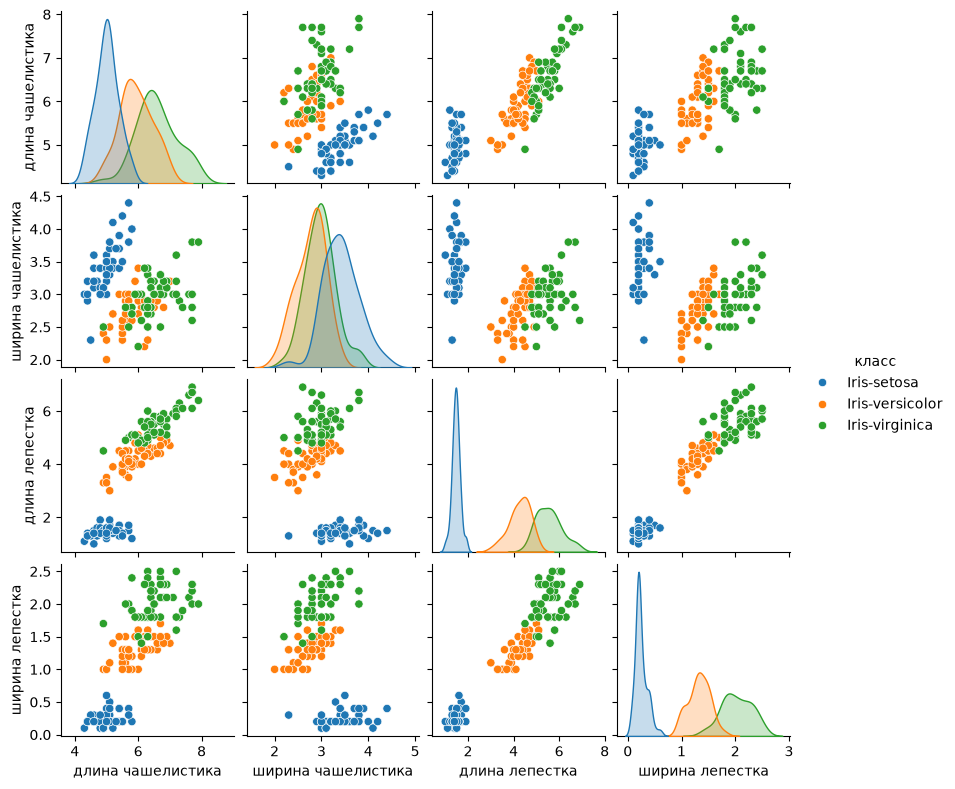

In [5]:
sns.pairplot(dataset, hue='класс', height=2)
plt.show()

Из рисунка видно, что класс синих точек (Iris-setosa) легко отделяется от двух других цветов. Оранджевые и зеленные точки отделяются не так просто в каждой из проэкций, но все равно можно провести прямую, которая отделит оранджевые точки от зеленых.

## Построение модели
### Преобразование данных
Как было сказано ранее нам требуется решить задачу классификации на 3 класса. Но для наглядноси рассмотрим бинарную классификацию (классификацию на несколько классов рассмотрим в следующей лекции).

Чтобы исходную задачу преобразовать в задачу бинарной классификации уберем из выборки все объекта класса Iris-setosa.

In [6]:
binary_dataset = dataset.drop(index=dataset.index[dataset['класс'] == 'Iris-setosa'])

Классы закодируем целыми числами $-1$ и $1$.

In [7]:
#Классы кодируем целыми числами -1 и 1
binary_dataset['класс'] = binary_dataset['класс'].map(
    {'Iris-versicolor': -1, 'Iris-virginica': 1})

Получаем задачу бинарной классификации.

### Модель алгоритмов

Модель алгоритмов $\mathfrak{F}$ в машинном обучении это некоторое множество функций, которые действуют из множества объектов в множество ответов, в нашем случае:
$$\mathfrak{F} = \{f| f: \mathbb{R}^n \to \{-1, 1\}, \text{еще какие-то ограничения}\},$$
обычно $\mathfrak{F}$ это некоторое параметрическое семество функций, тоесть разные функции $f$ отличаются друг от друга только каким-то параметром. Простым примером параметрическим семейством функций для задачи бинарной классификации является семейство линейный классификатор:
$$\mathfrak{F}_{bcl} = \left\{f\bigr(\theta, \mathbf{x}\bigr)=\text{sign}\bigr(\theta^{\mathsf{T}}\mathbf{x}\bigr)\bigr| \theta \in \mathbb{R}^{n} \right\}.$$


### Функция потерь

Машиное обучение это всегда выбор функции из множества $\mathfrak{F}$. Чтобы выбрать функцию, нужен некоторый критерий по которому она выбирается, то есть нужно упоррядочить все функции от худшей к лучшей. Для этого построем функционал $\mathcal{L}$, который каждой функции $f \in \mathfrak{F}$ ставит в соответствии число из $\mathbb{R}_+$. В машинном обучении обычно функционал качества водиться как некоторая ошибка на выборке. В общем виде функционал качества можно представить в следующем виде:
$$\mathcal{L}\bigr(f, \mathbf{X}, \mathbf{y}\bigr) = \sum_{i=1}^l\mathcal{q}\bigr(f, \mathbf{x}_i, y_i\bigr),$$
где $q$ некоторая функция ошибки на некотором объекте $\mathbf{x}$. Функционал качества $\mathcal{L}$ называется эмперическим риском.

### Оптимизационная задача

Далее нужно поставить задачу оптимизации для выбора $f \in \mathfrak{F}$. Здесь все просто, просто минимизируем эмперический риск:
$$\hat{f} = \arg \min_{f \in \mathfrak{F}} \mathcal{L}\bigr(f, \mathbf{X}, \mathbf{y}\bigr).$$

Важно! В результе функция $\hat{f}$ зависит от выборки $\left(\mathbf{X}, \mathbf{y}\right)$, то есть для разных наборов данных оптимальная функция будет различная.

Вернемся к нашей задаче. В нашем случае функционал качества будет иметь следующий вид:
$$\mathcal{L}\bigr(\theta, \mathbf{X}, \mathbf{y}\bigr) = \sum_{i=1}^l\bigr[f\bigr(\theta, \mathbf{x}_i\bigr) \not= y_i\bigr],$$
и оптимизационная задача переписывается в виде:
$$\hat{\theta} = \arg \min_{\theta \in \mathbb{R}^n} \sum_{i=1}^l\bigr[f\bigr(\theta, \mathbf{x}_i\bigr) \not= y_i\bigr].$$

И на самом деле в дальнейшем будем решать иммено такие задачи, на поиск оптимального параметра. Само решение задачи линейной бинарной классификации будет на следующей лекции. Сейчас используемся библиотеками для решения данной задачи. Далее в примере будет найден параметр $\hat{\theta}$ не как решение непосредственно этой оптимизационной задачи, а немного измененной, но об этом позже в следующей лекции.

### Поиск оптимального вектора параметров
Перейдем к двум матрицам:
1. Матрице объектов $\mathbf{X} \in \mathbb{R}^{l\times (n+1)}$
2. Вектору ответов $\mathbf{y} \in \{-1,1\}^l$

Заметим, что объекты мы погрузили в пространство более большой размерности, добавив еще один признак, который у всех объектов будет равен $1$.

In [8]:
X = binary_dataset.iloc[:, binary_dataset.columns != 'класс'].values
y = binary_dataset.iloc[:, binary_dataset.columns == 'класс'].values.reshape(-1)
X = np.array(np.hstack([X, np.ones([len(X), 1])]), dtype=np.float64)
y = np.array(y, dtype=np.int64)

In [9]:
model = LogisticRegression(random_state=0, max_iter=2000)
_ = model.fit(X, y)

Получаем вектор оптимальных параметров $\hat{\theta}$

In [10]:
model.coef_

array([[-3.94857799e-01, -5.12236925e-01,  2.93150207e+00,
         2.41616121e+00, -1.17463494e-03]])

Загрузите файл winequality-red.csv (с помощью pd.read_csv).

Последний столбец отвечает за качество вина. Будем считать, что хорошее вино начинается с цифры 7 и выше. 
Остальное вино будем счиатать некачественным.

Сделайте классификацию вина по данному датасету. Два класса "Хорошее" и "Не качественное". 
Результатом будем считать уравнение гиперповерхности на гиперпространстве параметров, отделяющее один класс от другого. 

## Решение практической работы

**Задача:** классификация красных вин по датасету `winequality-red.csv`
на два класса — «Хорошее» (quality ≥ 7) и «Некачественное»; результат —
уравнение разделяющей гиперповерхности. Дополнительно: применить модель
к классификации неизвестных вин, вычислить Accuracy, Precision, Recall
и вывести confusion matrix.

Схема решения повторяет лекционный пример: линейная модель
(LogisticRegression) в расширенном пространстве признаков (добавлен
признак, равный 1), классы закодированы числами $-1$ и $1$.

In [11]:
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, precision_score, recall_score)
from sklearn.model_selection import train_test_split

In [12]:
#Загрузим датасет и посмотрим на него
wine = pd.read_csv(r"winequality-red.csv")
display(wine.head())
print("Размер выборки:", wine.shape)
print("Распределение оценок quality:")
print(wine["quality"].value_counts().sort_index())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Размер выборки: (1599, 12)
Распределение оценок quality:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [13]:
#Множество объектов X — 11 признаков, к которым добавлен признак, равный 1.
#Множество ответов y: 1 — «Хорошее» (quality >= 7), -1 — «Некачественное»
y = np.where(wine["quality"] >= 7, 1, -1)
X = wine.drop(columns=["quality"]).to_numpy(float)
X = np.hstack([X, np.ones((len(X), 1))])
print("Хороших вин:", (y == 1).sum(), ", некачественных:", (y == -1).sum())

Хороших вин: 217 , некачественных: 1382


**Задача машинного обучения:** $|\mathbf{y}| = 2 \ll l = 1599$ —
задача бинарной классификации. Модель алгоритмов — семейство линейных
классификаторов
$\mathfrak{F} = \{ f(\theta, \mathbf{x}) = \operatorname{sign}(\theta^{\mathsf{T}}\mathbf{x}) \}$.

Часть выборки отложим как «неизвестные вина» — к ним модуль будет
применён после обучения. Разбиение стратифицированное, чтобы сохранить
доли классов (вин класса «Хорошее» заметно меньше):

In [14]:
#Откладываем 30% выборки как «неизвестные» вина
X_train, X_unknown, y_train, y_unknown = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y)
print("Обучающая выборка:", len(X_train), "вин, неизвестные вина:", len(X_unknown))

Обучающая выборка: 1119 вин, неизвестные вина: 480


In [15]:
#Обучаем модель на обучающей выборке
model = LogisticRegression(random_state=0, max_iter=5000)
model.fit(X_train, y_train)

#Уравнение гиперповерхности, отделяющей один класс от другого: theta^T x = 0
theta = model.coef_[0]
names = list(wine.columns[:-1]) + ["1"]
print("Разделяющая гиперповерхность:")
print(" ".join(f"{t:+.4f}·{n}" for t, n in zip(theta, names)), "= 0")

Разделяющая гиперповерхность:
+0.1279·fixed acidity -2.2288·volatile acidity +0.4692·citric acid +0.1469·residual sugar -0.7468·chlorides +0.0065·free sulfur dioxide -0.0131·total sulfur dioxide -0.0229·density -0.6891·pH +2.1931·sulphates +1.1850·alcohol +0.0092·1 = 0


### Классификация неизвестных вин

In [16]:
#Применяем обученную модель к классификации неизвестных вин
y_pred = model.predict(X_unknown)
label = {1: "Хорошее", -1: "Некачественное"}
result = pd.DataFrame({"истинный класс": [label[v] for v in y_unknown],
                       "предсказание модели": [label[v] for v in y_pred]})
display(result.head(10))
print("Правильно классифицировано:", (y_pred == y_unknown).sum(),
      "из", len(y_unknown))

,истинный класс,предсказание модели
0,Некачественное,Хорошее
1,Некачественное,Некачественное
2,Некачественное,Некачественное
3,Некачественное,Некачественное
4,Хорошее,Некачественное
5,Хорошее,Некачественное
6,Некачественное,Некачественное
7,Некачественное,Некачественное
8,Некачественное,Некачественное
9,Некачественное,Некачественное


Правильно классифицировано: 410 из 480


### Метрики классификации

In [17]:
#Accuracy, Precision и Recall (положительный класс — «Хорошее»)
print("Accuracy: ", accuracy_score(y_unknown, y_pred))
print("Precision:", precision_score(y_unknown, y_pred, pos_label=1))
print("Recall:   ", recall_score(y_unknown, y_pred, pos_label=1))
print()
print(classification_report(y_unknown, y_pred,
                            labels=[-1, 1],
                            target_names=["Некачественное", "Хорошее"]))

Accuracy:  0.8541666666666666
Precision: 0.43902439024390244
Recall:    0.27692307692307694

                precision    recall  f1-score   support

Некачественное       0.89      0.94      0.92       415
       Хорошее       0.44      0.28      0.34        65

      accuracy                           0.85       480
     macro avg       0.67      0.61      0.63       480
  weighted avg       0.83      0.85      0.84       480



,Некачественное,Хорошее
Некачественное,392,23
Хорошее,47,18


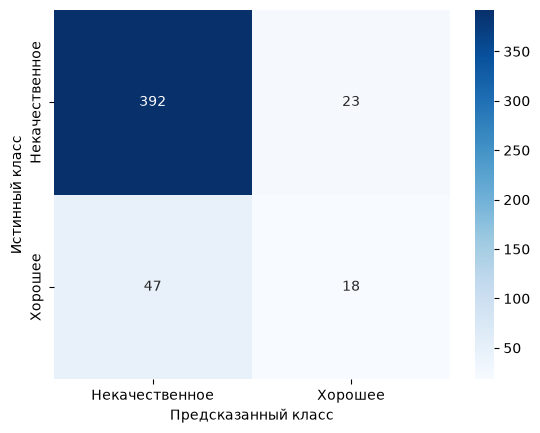

In [18]:
#Confusion matrix
cm = confusion_matrix(y_unknown, y_pred, labels=[-1, 1])
cm_df = pd.DataFrame(cm,
                     index=["Некачественное", "Хорошее"],
                     columns=["Некачественное", "Хорошее"])
display(cm_df)

plt.figure()
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

**Вывод.** Разделяющая гиперповерхность построена в
12-мерном пространстве (11 признаков + константа); наибольший вклад
вносят `volatile acidity` (отрицательный) и `alcohol` (положительный),
то есть хорошее вино — с меньшей летучей кислотностью и большей
крепостью.

На неизвестных винах модель даёт accuracy $\approx 0{,}85$: почти все
некачественные вина опознаются верно, однако recall «Хорошего» класса
невысок ($\approx 0{,}28$) — из-за сильного дисбаланса классов
(хороших вин всего $\approx 14\%$) модель редко рискует присваивать
класс «Хорошее». Confusion matrix показывает это явно: из всех
истинно хороших вин модель находит лишь около трети.